In [1]:
import pandas as pd

In [2]:
purchase_behaviour = pd.read_csv("QVI_purchase_behaviour.csv")

In [3]:
purchase_behaviour

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [4]:
purchase_behaviour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [5]:
purchase_behaviour.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [6]:
purchase_behaviour["PREMIUM_CUSTOMER"].unique()

array(['Premium', 'Mainstream', 'Budget'], dtype=object)

In [7]:
purchase_behaviour.duplicated().sum()

0

In [8]:
transaction = pd.read_excel("QVI_transaction_data.xlsx")

In [9]:
transaction.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [10]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [11]:
transaction.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [12]:
transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [13]:
print(transaction['PROD_NAME'].describe())

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object


In [14]:
transaction['PROD_NAME'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

In [15]:
productWords = (
    transaction['PROD_NAME']
    .drop_duplicates()
    .str.split()
    .explode()
)

productWords

0          Natural
0             Chip
0           Compny
0      SeaSalt175g
1              CCs
          ...     
549           150g
689        Doritos
689          Salsa
689           Mild
689           300g
Name: PROD_NAME, Length: 589, dtype: object

In [16]:
# Remove digits & special characters
productWords = productWords[
    productWords.str.contains('^[A-Za-z]+$', regex=True)
]

productWords

0        Natural
0           Chip
0         Compny
1            CCs
1          Nacho
         ...    
549          Cut
549    Bolognese
689      Doritos
689        Salsa
689         Mild
Name: PROD_NAME, Length: 437, dtype: object

In [17]:
word_counts = productWords.value_counts()
print(word_counts.head(20))

Chips       21
Smiths      16
Crinkle     14
Cut         14
Kettle      13
Cheese      12
Salt        12
Original    10
Chip         9
Doritos      9
Salsa        9
Pringles     8
Corn         8
RRD          8
WW           7
Chicken      7
Sour         6
Sea          6
Crisps       5
Thins        5
Name: PROD_NAME, dtype: int64


In [70]:
#There are salsa products in the dataset but we are only interested in the chips category, so let's remove these.
transaction = transaction[~transaction['PROD_NAME'].str.lower().str.contains('salsa')]



In [71]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 246742 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            246742 non-null  int64  
 1   STORE_NBR       246742 non-null  int64  
 2   LYLTY_CARD_NBR  246742 non-null  int64  
 3   TXN_ID          246742 non-null  int64  
 4   PROD_NBR        246742 non-null  int64  
 5   PROD_NAME       246742 non-null  object 
 6   PROD_QTY        246742 non-null  int64  
 7   TOT_SALES       246742 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.9+ MB


In [72]:
 264836-246742 

18094

In [19]:
transaction.duplicated().sum()                                                          

1

In [20]:
duplicates_row = transaction[transaction.duplicated()]

In [21]:
duplicates_row

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [22]:
transaction.iloc[124843:124846,:]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
134019,43561,250,250325,252790,87,Infuzions BBQ Rib Prawn Crackers 110g,2,7.6
134020,43376,250,250353,252907,26,Pringles Sweet&Spcy BBQ 134g,2,7.4
134021,43502,250,250353,252908,16,Smiths Crinkle Chips Salt & Vinegar 330g,2,11.4


In [73]:
transaction_1 = transaction.drop_duplicates()

In [74]:
transaction_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 246741 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            246741 non-null  int64  
 1   STORE_NBR       246741 non-null  int64  
 2   LYLTY_CARD_NBR  246741 non-null  int64  
 3   TXN_ID          246741 non-null  int64  
 4   PROD_NBR        246741 non-null  int64  
 5   PROD_NAME       246741 non-null  object 
 6   PROD_QTY        246741 non-null  int64  
 7   TOT_SALES       246741 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.9+ MB


In [75]:
transaction_1 = transaction_1.reset_index(drop=True)

In [76]:
transaction_1

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
246736,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
246737,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
246738,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
246739,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [77]:
# convert integer (Excel series date) to date 
transaction_1['DATE_CLEANED'] = pd.to_datetime(transaction['DATE'], unit='D', origin='1899-12-30')

In [78]:
# Extract Month
transaction_1['Purchase_Month'] = transaction_1['DATE_CLEANED'].dt.strftime('%B')

In [79]:
# Extract Year
transaction_1['Purchase_Year'] = transaction_1['DATE_CLEANED'].dt.strftime('%Y')

In [87]:
# Extract WeekDay
transaction_1['Purchase_WeekDay'] = transaction_1['DATE_CLEANED'].dt.strftime('%a')

In [31]:
# Format date to mm-dd-yyyy 
transaction_1['DATE_CLEANED'] = transaction_1['DATE_CLEANED'].dt.strftime('%m/%d/%Y')

In [88]:
transaction_1

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,DATE_CLEANED,Purchase_Month,Purchase_Year,PROD_NAME_CLEANED,PACKET_SIZE (g),BRAND,Purchase_WeekDay
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10-17,October,2018,Natural Chip Compny SeaSalt175g,175,Natural,Wed
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05-14,May,2019,CCs Nacho Cheese 175g,175,CCs,Tue
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05-20,May,2019,Smiths Crinkle Cut Chips Chicken 170g,170,Smiths,Mon
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08-17,August,2018,Smiths Chip Thinly S/Cream&Onion 175g,175,Smiths,Fri
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08-18,August,2018,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150,Kettle,Sat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246736,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,2019-06-17,June,2019,Kettle Sweet Chilli And Sour Cream 175g,175,Kettle,Mon
246737,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,2019-06-23,June,2019,Tostitos Splash Of Lime 175g,175,Tostitos,Sun
246738,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,2019-06-23,June,2019,Doritos Mexicana 170g,170,Doritos,Sun
246739,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,2019-01-24,January,2019,Doritos Corn Chip Mexican Jalapeno 150g,150,Doritos,Thu


In [81]:
# replace 2 or more space with single space
transaction_1['PROD_NAME_CLEANED'] = transaction_1['PROD_NAME'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [82]:
transaction_1['PACKET_SIZE (g)'] = transaction_1['PROD_NAME_CLEANED'].str.extract('(\d+)')

In [83]:
transaction_1['BRAND'] = transaction_1['PROD_NAME_CLEANED'].str.split().str[0]

In [84]:
transaction_1

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,DATE_CLEANED,Purchase_Month,Purchase_Year,PROD_NAME_CLEANED,PACKET_SIZE (g),BRAND
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10-17,October,2018,Natural Chip Compny SeaSalt175g,175,Natural
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05-14,May,2019,CCs Nacho Cheese 175g,175,CCs
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05-20,May,2019,Smiths Crinkle Cut Chips Chicken 170g,170,Smiths
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08-17,August,2018,Smiths Chip Thinly S/Cream&Onion 175g,175,Smiths
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08-18,August,2018,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150,Kettle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246736,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,2019-06-17,June,2019,Kettle Sweet Chilli And Sour Cream 175g,175,Kettle
246737,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,2019-06-23,June,2019,Tostitos Splash Of Lime 175g,175,Tostitos
246738,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,2019-06-23,June,2019,Doritos Mexicana 170g,170,Doritos
246739,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,2019-01-24,January,2019,Doritos Corn Chip Mexican Jalapeno 150g,150,Doritos


In [156]:
transaction_1['BRAND'].value_counts()

Kettle        41288
Smiths        27389
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3185
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: BRAND, dtype: int64

In [178]:
transaction_1['BRAND'].replace({'RRD':'Red','Snbts':'Sunbites','Infzns':'Infuzions',
                      'WW':'Woolworths','Smith':'Smiths','NCC':'Natural','Dorito':'Doritos','Grain':'GrnWves'},inplace=True)

In [179]:
transaction_1.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'DATE_CLEANED', 'Purchase_Month',
       'Purchase_Year', 'PROD_NAME_CLEANED', 'PACKET_SIZE (g)', 'BRAND',
       'Purchase_WeekDay'],
      dtype='object')

In [180]:
# re-order columns
transaction_2 = transaction_1[['DATE','DATE_CLEANED', 'Purchase_Month',
       'Purchase_Year', 'Purchase_WeekDay', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR','BRAND'
       ,'PROD_NAME','PROD_NAME_CLEANED','PACKET_SIZE (g)','PROD_QTY', 'TOT_SALES' ]]

In [181]:
transaction_2

,DATE,DATE_CLEANED,Purchase_Month,Purchase_Year,Purchase_WeekDay,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,BRAND,PROD_NAME,PROD_NAME_CLEANED,PACKET_SIZE (g),PROD_QTY,TOT_SALES
0,43390,2018-10-17,October,2018,Wed,1,1000,1,5,Natural,Natural Chip Compny SeaSalt175g,Natural Chip Compny SeaSalt175g,175,2,6.0
1,43599,2019-05-14,May,2019,Tue,1,1307,348,66,CCs,CCs Nacho Cheese 175g,CCs Nacho Cheese 175g,175,3,6.3
2,43605,2019-05-20,May,2019,Mon,1,1343,383,61,Smiths,Smiths Crinkle Cut Chips Chicken 170g,Smiths Crinkle Cut Chips Chicken 170g,170,2,2.9
3,43329,2018-08-17,August,2018,Fri,2,2373,974,69,Smiths,Smiths Chip Thinly S/Cream&Onion 175g,Smiths Chip Thinly S/Cream&Onion 175g,175,5,15.0
4,43330,2018-08-18,August,2018,Sat,2,2426,1038,108,Kettle,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150,3,13.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246736,43533,2019-06-17,June,2019,Mon,272,272319,270088,89,Kettle,Kettle Sweet Chilli And Sour Cream 175g,Kettle Sweet Chilli And Sour Cream 175g,175,2,10.8
246737,43325,2019-06-23,June,2019,Sun,272,272358,270154,74,Tostitos,Tostitos Splash Of Lime 175g,Tostitos Splash Of Lime 175g,175,1,4.4
246738,43410,2019-06-23,June,2019,Sun,272,272379,270187,51,Doritos,Doritos Mexicana 170g,Doritos Mexicana 170g,170,2,8.8
246739,43461,2019-01-24,January,2019,Thu,272,272379,270188,42,Doritos,Doritos Corn Chip Mexican Jalapeno 150g,Doritos Corn Chip Mexican Jalapeno 150g,150,2,7.8


# Outliers

In [161]:
import seaborn as sns

<AxesSubplot:>

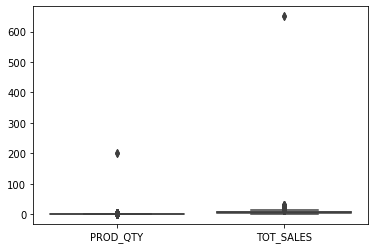

In [162]:
sns.boxplot(data=transaction_2[['PROD_QTY', 'TOT_SALES']])

In [163]:
outliers = transaction_2[transaction_2['PROD_QTY']==200]

In [164]:
customerID = outliers['LYLTY_CARD_NBR'].iloc[0]
purchase_behaviour[purchase_behaviour['LYLTY_CARD_NBR'] == customerID]

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
59694,226000,OLDER FAMILIES,Premium


In [165]:
transaction_2[transaction_2['TOT_SALES']==650]

,DATE,DATE_CLEANED,Purchase_Month,Purchase_Year,Purchase_WeekDay,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,BRAND,PROD_NAME,PROD_NAME_CLEANED,PACKET_SIZE (g),PROD_QTY,TOT_SALES
64955,43331,2019-05-04,May,2019,Sat,226,226000,226201,4,Doritos,Dorito Corn Chp Supreme 380g,Dorito Corn Chp Supreme 380g,380,200,650.0
64956,43605,2019-05-25,May,2019,Sat,226,226000,226210,4,Doritos,Dorito Corn Chp Supreme 380g,Dorito Corn Chp Supreme 380g,380,200,650.0


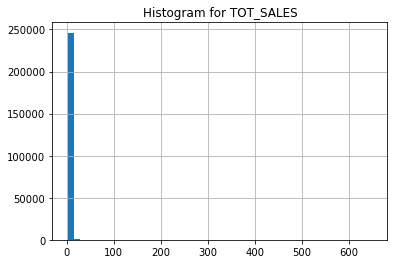

In [166]:
import matplotlib.pyplot as plt
transaction_2['TOT_SALES'].hist(bins=50)
plt.title("Histogram for TOT_SALES")
plt.show()

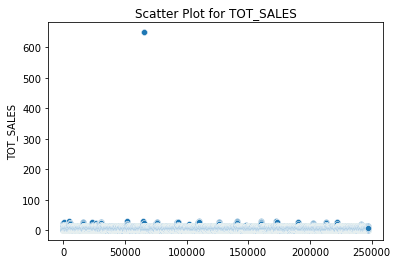

In [167]:
sns.scatterplot(x=range(len(transaction_2['TOT_SALES'])), y=transaction_2['TOT_SALES'])
plt.title("Scatter Plot for TOT_SALES")
plt.show()

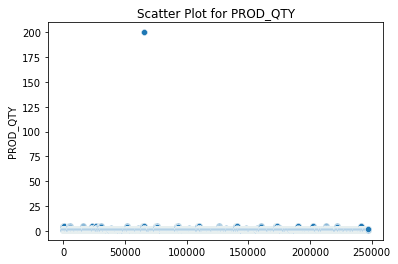

In [168]:
sns.scatterplot(x=range(len(transaction_2['PROD_QTY'])), y=transaction_2['PROD_QTY'])
plt.title("Scatter Plot for PROD_QTY")
plt.show()

In [169]:
transaction_2['PROD_QTY'].unique()

array([  2,   3,   5,   1,   4, 200], dtype=int64)

In [170]:
transaction_2['TOT_SALES'].unique()

array([  6.  ,   6.3 ,   2.9 ,  15.  ,  13.8 ,   5.7 ,   3.6 ,   3.9 ,
         7.2 ,  23.  ,   9.2 ,   1.7 ,   3.3 ,   2.1 ,   3.  ,   3.8 ,
         5.4 ,   2.7 ,   3.7 ,  14.8 ,   4.4 ,   6.6 ,   2.6 ,   3.25,
         4.6 ,   5.8 ,  15.5 ,   7.8 ,   4.2 ,   7.4 ,   7.6 ,   8.4 ,
         6.5 ,   4.3 ,  28.5 ,   3.4 ,  19.  ,  11.8 ,  17.6 ,   9.  ,
        13.2 ,   1.9 ,  13.  ,  15.2 ,  11.4 ,  14.5 ,   5.6 ,  10.8 ,
        10.4 ,  16.5 ,   1.8 ,   5.2 ,   5.9 ,  18.4 ,   8.8 ,  18.5 ,
         6.2 ,   4.8 ,   8.6 ,   2.8 ,   2.3 ,   3.1 ,   2.4 ,  15.6 ,
        19.5 ,  27.  ,   9.9 ,  16.2 ,  13.5 ,  21.6 ,  23.6 ,  29.5 ,
        12.6 ,   8.1 ,  11.1 ,  22.  ,   9.5 ,  16.25,  11.7 ,  22.8 ,
         9.6 ,   8.5 ,  10.5 ,  21.  ,  12.  ,  14.4 ,   5.1 ,   9.75,
        16.8 ,  17.7 ,  17.2 ,  17.1 ,   6.8 ,  18.  ,  12.9 ,  11.5 ,
         8.7 ,  14.  ,  11.6 ,  12.4 , 650.  ,  21.5 ,   9.3 ,  11.2 ,
         6.9 ])

In [171]:
Q1 = transaction_2['PROD_QTY'].quantile(0.25)
Q3 = transaction_2['PROD_QTY'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'lower bownd: {lower_bound} and upper bound: {upper_bound}')

outliers = transaction_2[(transaction_2['PROD_QTY'] < lower_bound) | (transaction_2['PROD_QTY'] > upper_bound)]
print("Outliers:\n")
print(len(outliers))

lower bownd: 2.0 and upper bound: 2.0
Outliers:

26672


In [172]:
from scipy import stats
import numpy as np
import pandas as pd

z = np.abs(stats.zscore(transaction_2['PROD_QTY']))
print("Z-Score Values:\n", z)

outliers = transaction_2[z > 3]
print("Outliers:\n", len(outliers))

Z-Score Values:
 0         0.139336
1         1.654876
2         0.139336
3         4.685955
4         1.654876
            ...   
246736    0.139336
246737    1.376203
246738    0.139336
246739    0.139336
246740    0.139336
Name: PROD_QTY, Length: 246741, dtype: float64
Outliers:
 788


In [173]:
28797/264835 * 100

10.873562784375176

In [182]:
transaction_2 = transaction_2[transaction_2['LYLTY_CARD_NBR']!=customerID]

In [183]:
transaction_2.to_csv('Transaction_CLEANED.csv')

# Merge 2 dataset (purchase and transaction)

In [184]:
df = pd.merge(purchase_behaviour,transaction_2,on='LYLTY_CARD_NBR')

df['DATE_CLEANED'] = pd.to_datetime(df['DATE_CLEANED'])

df1 = df.sort_values(by='DATE_CLEANED',ascending=True)

# Transactions over Time

In [97]:
# pd.set_option('display.max.rows',365)
# pivot_1 = df1.pivot_table(index='DATE_CLEANED', values='TOT_SALES', aggfunc='sum',margins=True)


# pivot_1

transactions_by_day = (
    df1.groupby('DATE_CLEANED')
    .size() #counts the number of rows in each group
    .reset_index(name='N')
)

transactions_by_day

,DATE_CLEANED,N
0,2018-07-01,623
1,2018-07-02,609
2,2018-07-03,612
3,2018-07-04,624
4,2018-07-05,624
...,...,...
359,2019-06-26,603
360,2019-06-27,624
361,2019-06-28,621
362,2019-06-29,653


In [98]:
date_range = pd.date_range('2018-07-01','2019-06-30')
date_range = pd.DataFrame({'DATE_CLEANED': date_range})

In [99]:
transactions_by_day = pd.merge(date_range,transactions_by_day,on='DATE_CLEANED',how='left').fillna(0)

transactions_by_day

,DATE_CLEANED,N
0,2018-07-01,623.0
1,2018-07-02,609.0
2,2018-07-03,612.0
3,2018-07-04,624.0
4,2018-07-05,624.0
...,...,...
360,2019-06-26,603.0
361,2019-06-27,624.0
362,2019-06-28,621.0
363,2019-06-29,653.0


Text(0.5, 1.0, 'Overall Sales')

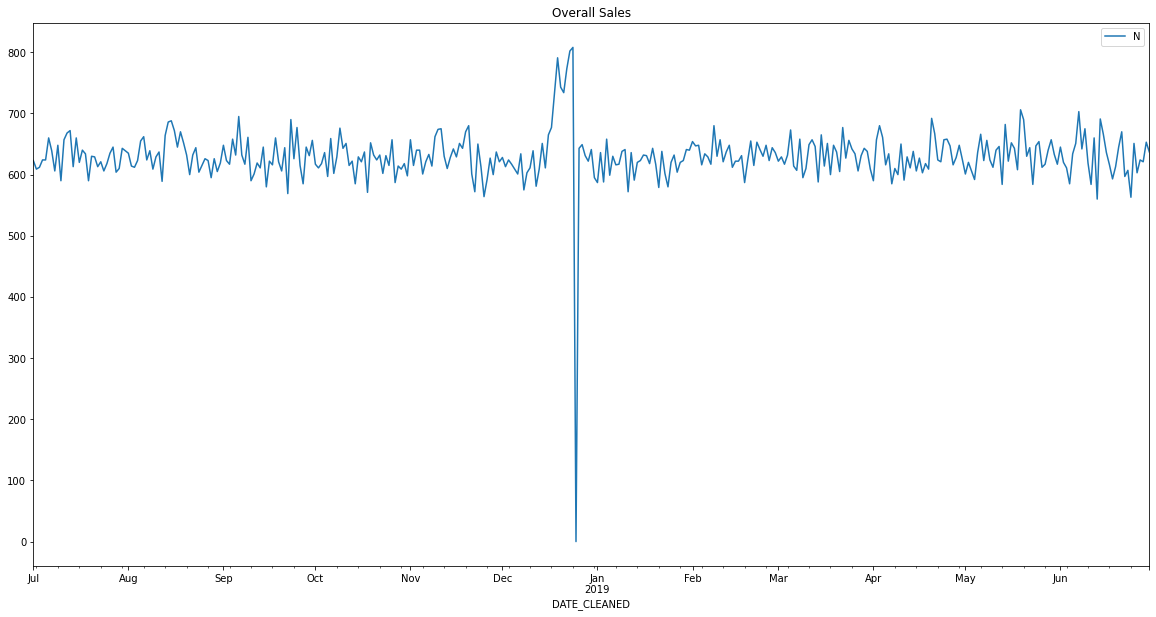

In [100]:
transactions_by_day.plot(x='DATE_CLEANED',y='N',figsize=(20,10))
plt.title('Overall Sales')

Text(0.5, 1.0, 'December Transactions')

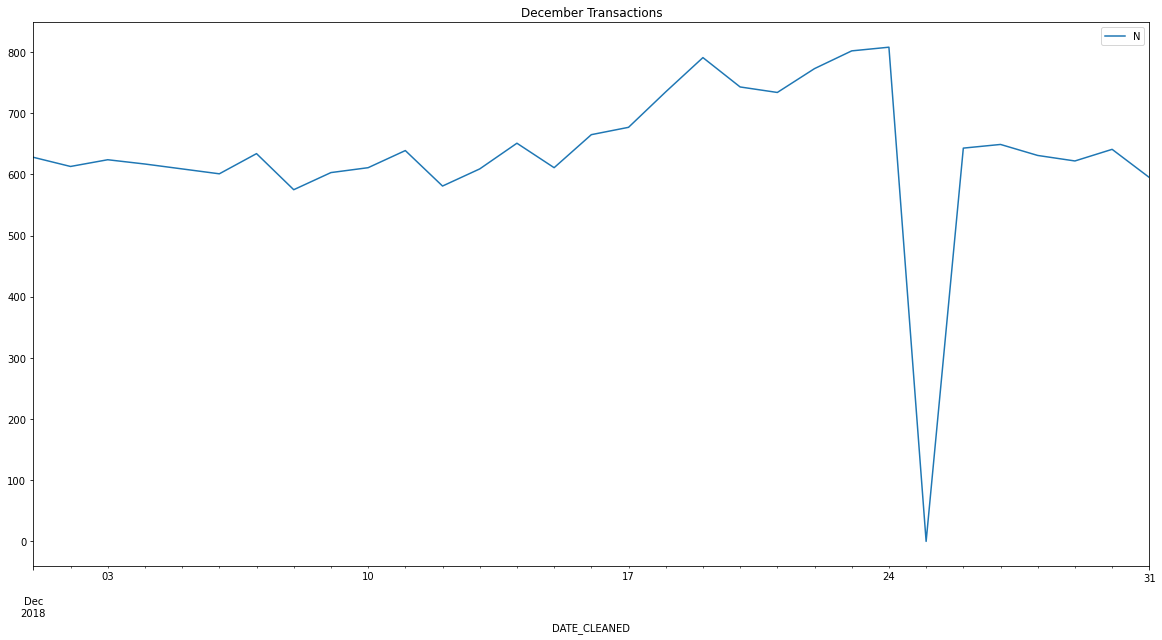

In [101]:
december = transactions_by_day[
    (transactions_by_day['DATE_CLEANED'] >= '2018-12-01') &
    (transactions_by_day['DATE_CLEANED'] <= '2018-12-31')
]
december.plot(x='DATE_CLEANED',y='N',figsize=(20,10))
plt.title('December Transactions')

# Packet Size

Text(0.5, 1.0, 'Packet Distribution')

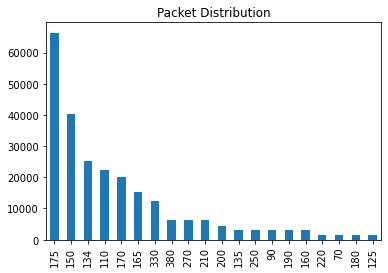

In [102]:
df1['PACKET_SIZE (g)'].value_counts().plot(kind='bar')

plt.title('Packet Distribution')

Text(0.5, 1.0, 'Total Sales over Packet Size')

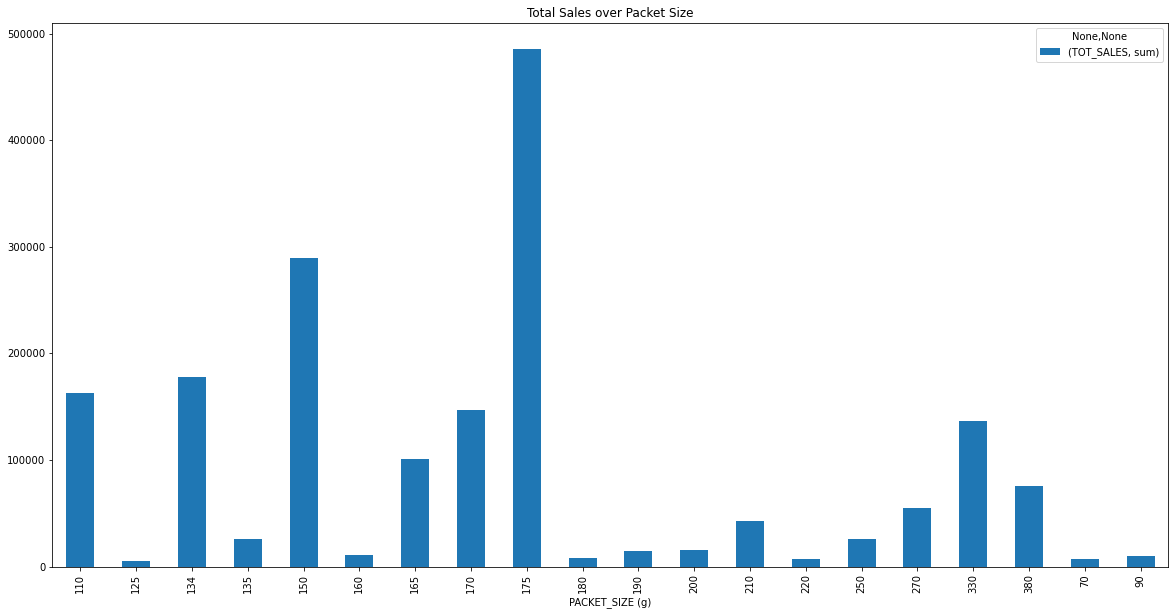

In [103]:
df1.groupby('PACKET_SIZE (g)').agg({'TOT_SALES':['sum']}).plot(kind='bar',figsize=(20,10))
plt.title('Total Sales over Packet Size')

Text(0.5, 1.0, 'Total Sales over Packet Size')

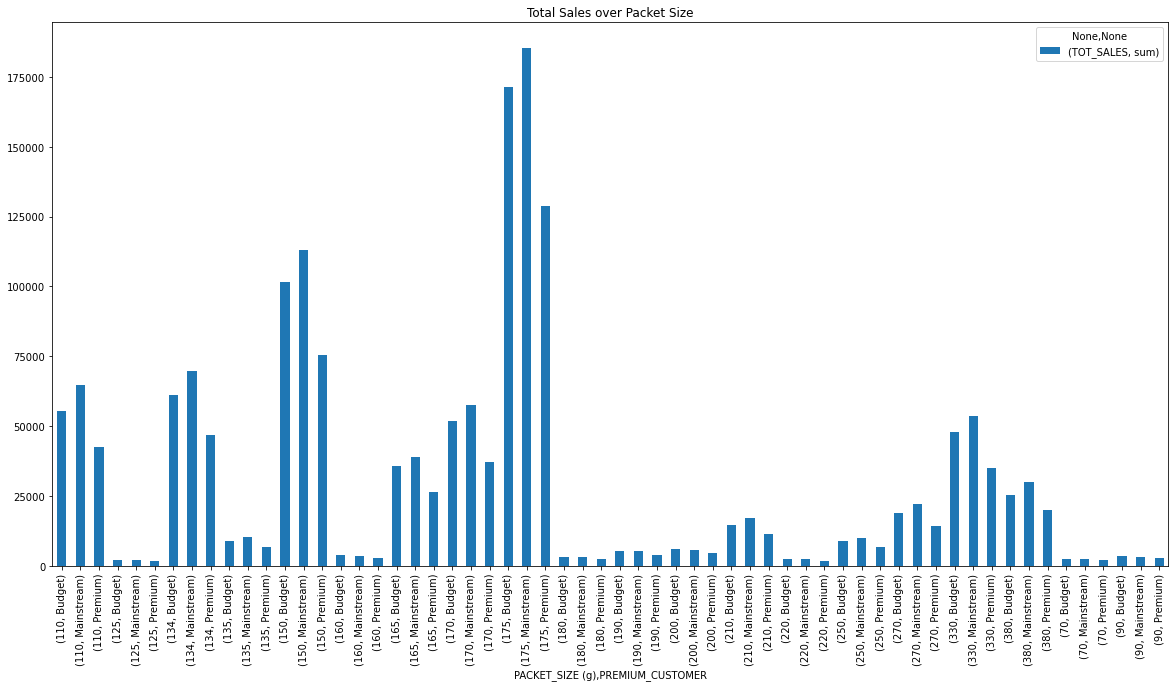

In [105]:
df1.groupby(['PACKET_SIZE (g)','PREMIUM_CUSTOMER']).agg({'TOT_SALES':['sum']}).plot(kind='bar',figsize=(20,10))
plt.title('Total Sales over Packet Size')

In [63]:
df1

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,DATE_CLEANED,Purchase_Month,Purchase_Year,Purchase_WeekDay,STORE_NBR,TXN_ID,PROD_NBR,BRAND,PROD_NAME,PROD_NAME_CLEANED,PACKET_SIZE (g),PROD_QTY,TOT_SALES
207816,226259,YOUNG SINGLES/COUPLES,Mainstream,43395,2018-07-01,July,2018,Sun,226,227609,70,Tyrrells,Tyrrells Crisps Lightly Salted 165g,Tyrrells Crisps Lightly Salted 165g,165,2,8.4
88454,97088,YOUNG SINGLES/COUPLES,Premium,43403,2018-07-01,July,2018,Sun,97,96837,2,Cobs,Cobs Popd Sour Crm &Chives Chips 110g,Cobs Popd Sour Crm &Chives Chips 110g,110,2,7.6
225583,243334,MIDAGE SINGLES/COUPLES,Premium,43490,2018-07-01,July,2018,Sun,243,247063,29,French,French Fries Potato Chips 175g,French Fries Potato Chips 175g,175,2,6.0
52131,60213,OLDER SINGLES/COUPLES,Mainstream,43377,2018-07-01,July,2018,Sun,60,57058,26,Pringles,Pringles Sweet&Spcy BBQ 134g,Pringles Sweet&Spcy BBQ 134g,134,2,7.4
104529,112123,YOUNG SINGLES/COUPLES,Mainstream,43642,2018-07-01,July,2018,Sun,112,114504,29,French,French Fries Potato Chips 175g,French Fries Potato Chips 175g,175,2,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246632,272349,YOUNG FAMILIES,Budget,43583,NaT,NaN,NaN,NaN,272,270140,32,Kettle,Kettle Sea Salt And Vinegar 175g,Kettle Sea Salt And Vinegar 175g,175,2,10.8
246651,272361,OLDER SINGLES/COUPLES,Mainstream,43471,NaT,NaN,NaN,NaN,272,270159,46,Kettle,Kettle Original 175g,Kettle Original 175g,175,2,10.8
246697,861921,OLDER SINGLES/COUPLES,Premium,43642,NaT,NaN,NaN,NaN,155,85336,4,Dorito,Dorito Corn Chp Supreme 380g,Dorito Corn Chp Supreme 380g,380,2,13.0
246698,861951,RETIREES,Budget,43642,NaT,NaN,NaN,NaN,155,85355,28,Thins,Thins Potato Chips Hot & Spicy 175g,Thins Potato Chips Hot & Spicy 175g,175,2,6.6


# Brand Name

In [185]:
df1.groupby('BRAND').agg({'TXN_ID':'count','TOT_SALES':'sum'})

,TXN_ID,TOT_SALES
BRAND,,
Burger,1564,6831.0
CCs,4551,18078.9
Cheetos,2927,16884.5
Cheezels,4603,40029.9
Cobs,9693,70569.8
Doritos,25224,226329.9
French,1418,7929.0
GrnWves,7740,51617.2
Infuzions,14201,99047.6


In [152]:
1576+3144+2963+1419+3183+6272+11894

30451

<AxesSubplot:ylabel='BRAND'>

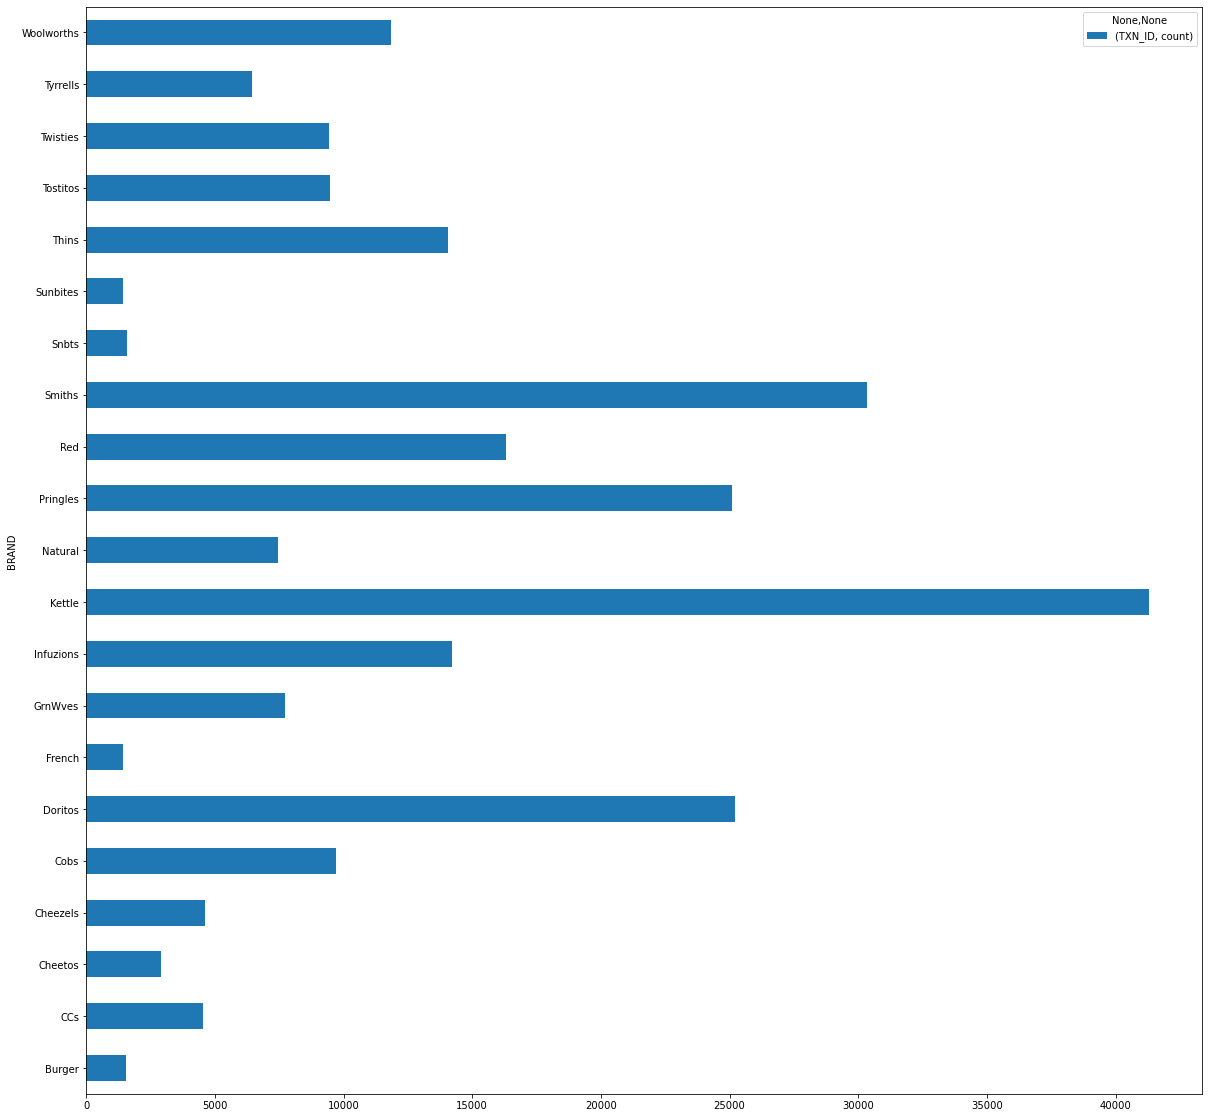

In [155]:
df1.groupby('BRAND').agg({'TXN_ID':['count']}).plot.barh(figsize=(20,20))

# Total sales by Segment

In [121]:
df1.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg({'TOT_SALES':['sum']})

TOT_SALES
                                               sum
LIFESTAGE              PREMIUM_CUSTOMER           
MIDAGE SINGLES/COUPLES Budget             33345.70
                       Mainstream         84734.25
                       Premium            54443.85
NEW FAMILIES           Budget             20607.45
                       Mainstream         15979.70
                       Premium            10760.80
OLDER FAMILIES         Budget            156863.75
                       Mainstream         96413.55
                       Premium            75242.60
OLDER SINGLES/COUPLES  Budget            127833.60
                       Mainstream        124648.50
                       Premium           123531.55
RETIREES               Budget            105916.30
                       Mainstream        145168.95
                       Premium            91296.65
YOUNG FAMILIES         Budget            129717.95
                       Mainstream         86338.25
                       Premium            78571.70
YOUNG SINGLES/COUPLES  Budget             57122.10
                       Mainstream        147582.20
                       Premium            39052.30

# Avg units per customer

In [137]:
df1.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg({'PROD_QTY':'sum','TOT_SALES':'sum','LYLTY_CARD_NBR': 'nunique'})

PROD_QTY  TOT_SALES  LYLTY_CARD_NBR
LIFESTAGE              PREMIUM_CUSTOMER                                     
MIDAGE SINGLES/COUPLES Budget                8883   33345.70            1474
                       Mainstream           21213   84734.25            3298
                       Premium              14400   54443.85            2369
NEW FAMILIES           Budget                5241   20607.45            1087
                       Mainstream            4060   15979.70             830
                       Premium               2769   10760.80             575
OLDER FAMILIES         Budget               41853  156863.75            4611
                       Mainstream           25804   96413.55            2788
                       Premium              20239   75242.60            2231
OLDER SINGLES/COUPLES  Budget               32883  127833.60            4849
                       Mainstream           32607  124648.50            4858
                       Premium              31693  123531.55            4682
RETIREES               Budget               26932  105916.30            4385
                       Mainstream           37677  145168.95            6358
                       Premium              23266   91296.65            3812
YOUNG FAMILIES         Budget               34482  129717.95            3953
                       Mainstream           23194   86338.25            2685
                       Premium              20901   78571.70            2398
YOUNG SINGLES/COUPLES  Budget               15500   57122.10            3647
                       Mainstream           36225  147582.20            7917
                       Premium              10575   39052.30            2480

In [138]:
df1.groupby(['PREMIUM_CUSTOMER']).agg({'PROD_QTY':'sum','TOT_SALES':'sum'})

,PROD_QTY,TOT_SALES
PREMIUM_CUSTOMER,,
Budget,165774,631406.85
Mainstream,180780,700865.40
Premium,123843,472899.45


# Average price per unit

In [140]:
df1['UNIT_PRICE'] = df1['TOT_SALES'] / df1['PROD_QTY'] 

In [141]:
df1.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg({'UNIT_PRICE':['mean']})

UNIT_PRICE
                                              mean
LIFESTAGE              PREMIUM_CUSTOMER           
MIDAGE SINGLES/COUPLES Budget             3.743328
                       Mainstream         3.994241
                       Premium            3.770698
NEW FAMILIES           Budget             3.917688
                       Mainstream         3.916133
                       Premium            3.872110
OLDER FAMILIES         Budget             3.745340
                       Mainstream         3.737077
                       Premium            3.717000
OLDER SINGLES/COUPLES  Budget             3.882096
                       Mainstream         3.814665
                       Premium            3.893236
RETIREES               Budget             3.924404
                       Mainstream         3.844294
                       Premium            3.920942
YOUNG FAMILIES         Budget             3.760737
                       Mainstream         3.724533
                       Premium            3.762150
YOUNG SINGLES/COUPLES  Budget             3.657366
                       Mainstream         4.065642
                       Premium            3.665414

# T-test

In [147]:
df1[
    (df1['PREMIUM_CUSTOMER'].isin(['Budget', 'Premium']))&(df1['LIFESTAGE'].isin(['MIDAGE SINGLES/COUPLES','YOUNG SINGLES/COUPLES']))]['UNIT_PRICE']

88454     3.8
225583    3.0
210572    1.8
168558    4.4
113559    4.4
         ... 
246050    3.0
246308    4.4
246450    3.8
246553    4.4
246575    4.4
Name: UNIT_PRICE, Length: 26728, dtype: float64

In [148]:
from scipy.stats import ttest_ind

group1 = df1[
    (df1['PREMIUM_CUSTOMER'] == 'Mainstream')&(df1['LIFESTAGE'].isin(['MIDAGE SINGLES/COUPLES','YOUNG SINGLES/COUPLES']))]['UNIT_PRICE']

group2 = df1[
    (df1['PREMIUM_CUSTOMER'].isin(['Budget', 'Premium']))&(df1['LIFESTAGE'].isin(['MIDAGE SINGLES/COUPLES','YOUNG SINGLES/COUPLES']))]['UNIT_PRICE']

t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
print(p_value)


2.235645611540966e-309


# Deep dive: Mainstream young singles / couples

In [130]:
segment = df1[(df1['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (df1['PREMIUM_CUSTOMER'] == 'Mainstream')]

In [131]:
segment['BRAND'].value_counts()

Kettle        3844
Pringles      2315
Doritos       2076
Smiths        1790
Thins         1166
Infuzions      962
Twisties       900
Tostitos       890
Red            875
Cobs           864
Tyrrells       619
Grain          576
WW             423
Cheezels       346
Natural        321
Dorito         303
Infzns         288
CCs            222
Cheetos        166
Smith          131
French          78
NCC             73
Snbts           71
GrnWves         70
Burger          62
Sunbites        57
Woolworths      56
Name: BRAND, dtype: int64

In [134]:
segment['PACKET_SIZE (g)'].value_counts()

175    4997
150    3080
134    2315
110    2051
170    1575
330    1195
165    1102
380     626
270     620
210     576
135     290
250     280
200     179
190     148
160     128
90      128
180      70
70       63
220      62
125      59
Name: PACKET_SIZE (g), dtype: int64

In [ ]:
#Calculate Affinity on Tableau